# 0.6 Xatu EIP-8037 State-Gas Estimator

This notebook builds the scalable Xatu-side estimator for counterfactual EIP-8037 state gas.

It intentionally covers only the parts available from Xatu:

- Storage creations from transaction-indexed storage diffs.
- Contract code bytes from contract creation rows.
- New-account proxies from balance/nonce/contract candidates, with first-appearance filtering.
- CBT state-size inventory deltas as diagnostics.

It does **not** claim exact EIP-8037 state creation for account existence or EIP-7702 delegation indicators. Those are calibrated in the next notebook using an archive node.

## Setup

This cell loads the repo helpers and opens two Xatu connections:

- CBT Xatu for block headers, resource-gas diagnostics, and cumulative state-size snapshots.
- Raw Xatu for transaction-level diffs, which are the source of the counterfactual EIP-8037 counters.

Keeping both clients visible here makes it clear which data is diagnostic and which data feeds the replay estimator.

In [1]:
import os
from pathlib import Path

import clickhouse_connect
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from sim.xatu_state_growth import query_xatu_state_growth_by_block

pd.options.display.float_format = "{:,.4f}".format

load_dotenv(PROJECT_ROOT / ".env")
missing = [name for name in ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"] if not os.environ.get(name)]
if missing:
    raise RuntimeError("Missing .env values: " + ", ".join(missing))

CLICKHOUSE_CBT_HOST = os.environ.get("CLICKHOUSE_CBT_HOST", "clickhouse-cbt.xatu.ethpandaops.io")
CLICKHOUSE_RAW_HOST = os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io")

cbt_client = clickhouse_connect.get_client(
    host=CLICKHOUSE_CBT_HOST,
    port=443,
    secure=True,
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
)
raw_client = clickhouse_connect.get_client(
    host=CLICKHOUSE_RAW_HOST,
    port=443,
    secure=True,
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
)

print("cbt", CLICKHOUSE_CBT_HOST, cbt_client.query("SELECT version()").result_rows)
print("raw", CLICKHOUSE_RAW_HOST, raw_client.query("SELECT version()").result_rows)

cbt clickhouse-cbt.xatu.ethpandaops.io [('26.2.5.45',)]
raw clickhouse-raw.xatu.ethpandaops.io [('26.2.5.45',)]


## Parameters

The default range is the same recent 50-block window used by the calldata/BAL notebooks. The output CSV becomes the Xatu-side state input that the RPC calibration notebook compares against.

In [2]:
NETWORK = "mainnet"
START_BLOCK = 24_120_001
N_BLOCKS = 50
BLOCKS = list(range(START_BLOCK, START_BLOCK + N_BLOCKS))
CPSB = 1530

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)
OUT_CSV = DATA_DIR / f"xatu_state_growth_{min(BLOCKS)}_{max(BLOCKS)}.csv"
WRITE_CSV = True

min(BLOCKS), max(BLOCKS), len(BLOCKS), CPSB

(24120001, 24120050, 50, 1530)

## What Xatu Can And Cannot Recover

For EIP-8037 passive replay, the Xatu estimator is split by charge:

| EIP-8037 component | Xatu treatment | Replay status |
|---|---|---|
| New storage slots | Count transaction-level storage diffs with `from_value = 0` and `to_value != 0` | Good scalable estimator for committed net tx effects |
| Contract code bytes | Sum `canonical_execution_contracts.n_code_bytes` | Good scalable estimator |
| New accounts | Candidate proxy, first-appearance proxy, and CBT net-delta anchor | Not exact; needs pre-state calibration |
| EIP-7702 delegation indicators | Type-4 tx count only | Not exact from Xatu; needs RPC authorization list + pre-state |

The replay column from this notebook is `state_gas_used`, computed from the Xatu first-appearance account proxy. The RPC notebook measures the error of that proxy on a sample.

## Address Appearance Relationships

This diagnostic checks what `canonical_execution_address_appearances.relationship` actually contains in the sample. The goal is to see whether relationship labels can identify account creation directly. In practice they mostly describe references, so this table is evidence for why we do not use relationship as the main account-existence estimator.

In [3]:
relationship_counts = raw_client.query_df(
    """
    SELECT
        relationship,
        count() AS n
    FROM default.canonical_execution_address_appearances FINAL
    WHERE meta_network_name = {network:String}
      AND block_number BETWEEN {start_block:UInt64} AND {end_block:UInt64}
    GROUP BY relationship
    ORDER BY n DESC
    """,
    parameters={
        "network": NETWORK,
        "start_block": min(BLOCKS),
        "end_block": max(BLOCKS),
    },
)
relationship_counts

,relationship,n
0,call_from,99712
1,call_to,99712
2,erc20_transfer_from_to,23593
3,erc20_transfer_from,23593
4,tx_from,14989
5,miner_fee,14989
6,tx_to,14989
7,erc721_transfer_from_to,667
8,erc721_transfer_from,667
9,factory,64


The relationship values are useful diagnostics, but they are not a complete account-existence oracle. In the current sample, the creation-like labels are mainly `create` and `factory`; value-created accounts can still appear through ordinary reference relationships. So the main Xatu account estimator remains the first-appearance proxy plus explicit error calibration in the RPC notebook.

## Pull Xatu State-Growth Estimate

This is the core Xatu estimator. It reconstructs the EIP-8037 state-gas inputs from raw diffs, then joins CBT fields only as diagnostics. The replay-facing output is `state_gas_used`; historical CBT `gas_state_growth` is not used as the counterfactual EIP-8037 value.

In [4]:
state_growth = query_xatu_state_growth_by_block(
    cbt_client,
    BLOCKS,
    network=NETWORK,
    cpsb=CPSB,
    raw_client=raw_client,
)

preview_cols = [
    "block_number",
    "gas_used",
    "eip8037_new_storage_slots",
    "eip8037_zero_to_nonzero_storage_writes",
    "eip8037_code_bytes",
    "eip8037_new_account_candidates",
    "eip8037_new_accounts",
    "accounts_net_delta",
    "eip8037_type4_tx_count",
    "eip8037_state_bytes_equivalent",
    "state_gas_used",
]
state_growth[preview_cols].head()

,block_number,gas_used,eip8037_new_storage_slots,eip8037_zero_to_nonzero_storage_writes,eip8037_code_bytes,eip8037_new_account_candidates,eip8037_new_accounts,accounts_net_delta,eip8037_type4_tx_count,eip8037_state_bytes_equivalent,state_gas_used
0,24120001,59964904,244,244,1335,139,89,89.0000,1,27631,42275430
1,24120002,13753679,81,81,0,62,31,31.0000,3,8904,13623120
2,24120003,41015898,288,288,1217,205,71,71.0000,1,28169,43098570
3,24120004,23756933,178,178,3152,83,50,50.0000,1,20544,31432320
4,24120005,16941785,78,78,1087,64,23,23.0000,2,8839,13523670


## Account Proxy Band

This table is the account-existence sanity band. `raw_new_account_candidates` is intentionally loose, `accounts_net_delta_positive_sum` is a net inventory anchor, and `new_accounts_first_seen_proxy` is the scalable Xatu proxy that we later calibrate against RPC pre-state traces.

In [5]:
account_proxy_summary = pd.DataFrame(
    [
        {
            "blocks": len(state_growth),
            "accounts_net_delta_positive_sum": int(state_growth["accounts_net_delta"].clip(lower=0).sum()),
            "new_accounts_first_seen_proxy": int(state_growth["eip8037_new_accounts"].sum()),
            "raw_new_account_candidates": int(state_growth["eip8037_new_account_candidates"].sum()),
            "candidate_to_first_seen_ratio": (
                state_growth["eip8037_new_account_candidates"].sum()
                / state_growth["eip8037_new_accounts"].sum()
                if state_growth["eip8037_new_accounts"].sum()
                else pd.NA
            ),
            "first_seen_to_net_delta_ratio": (
                state_growth["eip8037_new_accounts"].sum()
                / state_growth["accounts_net_delta"].clip(lower=0).sum()
                if state_growth["accounts_net_delta"].clip(lower=0).sum()
                else pd.NA
            ),
        }
    ]
)
account_proxy_summary

,blocks,accounts_net_delta_positive_sum,new_accounts_first_seen_proxy,raw_new_account_candidates,candidate_to_first_seen_ratio,first_seen_to_net_delta_ratio
0,50,2672,2672,5527,2.0685,1.0000


Interpretation:

```text
accounts_net_delta_positive_sum <= new_accounts_first_seen_proxy <= raw_new_account_candidates
```

This is a sanity-check expectation, not a theorem. `accounts_net_delta` is a net inventory anchor, `raw_new_account_candidates` is overcount-prone, and the first-seen proxy is the Xatu estimator used for scalable replay until RPC calibration tells us its error.

## State-Gas Summary

This summary compresses the 50-block estimator into the quantities that matter for replay: storage slots, code bytes, new-account proxy, type-4 activity, and total EIP-8037 state gas.

In [6]:
summary = pd.DataFrame(
    [
        {
            "blocks": len(state_growth),
            "new_storage_slots": int(state_growth["eip8037_new_storage_slots"].sum()),
            "zero_to_nonzero_storage_writes": int(state_growth["eip8037_zero_to_nonzero_storage_writes"].sum()),
            "code_bytes": int(state_growth["eip8037_code_bytes"].sum()),
            "new_accounts_first_seen_proxy": int(state_growth["eip8037_new_accounts"].sum()),
            "type4_tx_count": int(state_growth["eip8037_type4_tx_count"].sum()),
            "new_delegation_indicators_xatu": int(state_growth["eip8037_new_delegation_indicators"].sum()),
            "state_bytes_equivalent": int(state_growth["eip8037_state_bytes_equivalent"].sum()),
            "state_gas_used": int(state_growth["state_gas_used"].sum()),
        }
    ]
)
summary

,blocks,new_storage_slots,zero_to_nonzero_storage_writes,code_bytes,new_accounts_first_seen_proxy,type4_tx_count,new_delegation_indicators_xatu,state_bytes_equivalent,state_gas_used
0,50,9066,9067,142457,2672,67,0,1043321,1596281130


## Plots

The plots are quick visual checks for spikes and estimator behavior. They are not the final analysis; they help catch obvious data-shape problems before the CSV feeds replay.

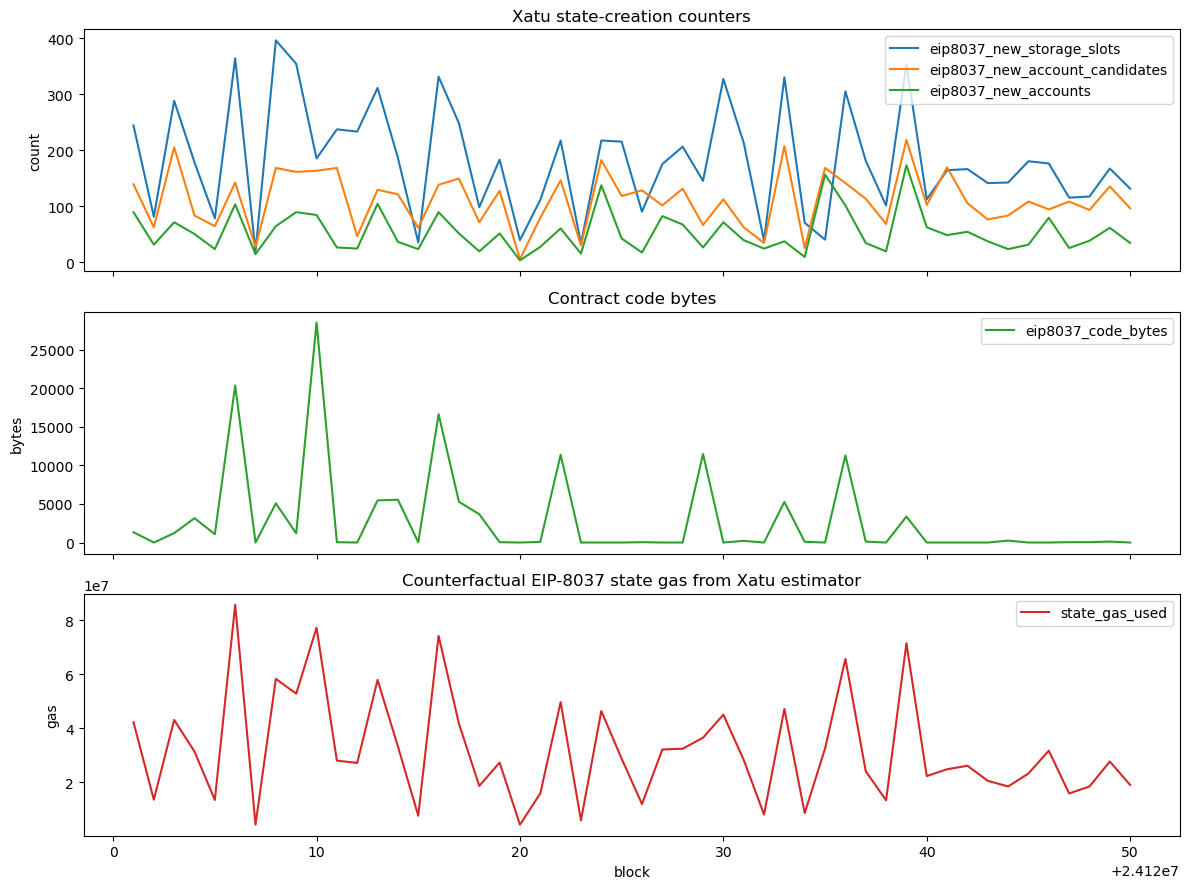

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
state_growth.plot(
    x="block_number",
    y=["eip8037_new_storage_slots", "eip8037_new_account_candidates", "eip8037_new_accounts"],
    ax=axes[0],
)
axes[0].set_title("Xatu state-creation counters")
axes[0].set_ylabel("count")

state_growth.plot(x="block_number", y="eip8037_code_bytes", ax=axes[1], color="tab:green")
axes[1].set_title("Contract code bytes")
axes[1].set_ylabel("bytes")

state_growth.plot(x="block_number", y="state_gas_used", ax=axes[2], color="tab:red")
axes[2].set_title("Counterfactual EIP-8037 state gas from Xatu estimator")
axes[2].set_ylabel("gas")
axes[2].set_xlabel("block")

fig.tight_layout()

## Export

Export the Xatu estimator. The RPC calibration notebook expects this CSV to exist and uses it as the baseline to compare against prestateTracer-derived counts.

In [8]:
if WRITE_CSV:
    state_growth.to_csv(OUT_CSV, index=False)
    print(OUT_CSV)

state_growth.columns.tolist()

/Users/william/PycharmProjects/eip-7999-research/data/xatu_state_growth_24120001_24120050.csv


['block_number',
 'timestamp',
 'gas_used',
 'gas_limit',
 'base_fee_per_gas',
 'gas_compute',
 'gas_memory',
 'gas_address_access',
 'gas_state_growth',
 'gas_history',
 'gas_bloom_topics',
 'gas_block_size',
 'gas_refund',
 'transaction_state_gas',
 'opcode_state_gas',
 'eip8037_new_storage_slots',
 'eip8037_zero_to_nonzero_storage_writes',
 'eip8037_new_contract_accounts',
 'eip8037_code_bytes',
 'eip8037_new_account_candidates',
 'eip8037_new_accounts',
 'eip8037_type4_tx_count',
 'accounts',
 'storages',
 'contract_codes',
 'account_bytes',
 'account_trienode_bytes',
 'contract_code_bytes',
 'storage_bytes',
 'storage_trienode_bytes',
 'total_state_bytes',
 'accounts_net_delta',
 'storages_net_delta',
 'contract_codes_net_delta',
 'contract_code_bytes_net_delta',
 'storage_bytes_net_delta',
 'total_state_bytes_net_delta',
 'state_size_source',
 'eip8037_new_delegation_indicators',
 'eip8037_state_bytes_equivalent',
 'eip8037_state_gas_used',
 'eip8037_state_gas_source',
 'state_ga